In [21]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

In [13]:
# URL del dataset
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"

# Cargar dataset
df = pd.read_csv(url)

# Mostrar primeras filas
print(df.head())

# Información general
print("\nInformación del dataset:")
print(df.info())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64


Estadísticas descriptivas:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      333.000000     333.000000         333.000000   333.000000   
mean        43.992793      17.164865         200.966967  4207.057057   
std          5.468668       1.969235          14.015765   805.215802   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.500000      15.600000         190.000000  3550.000000   
50%         44.500000      17.300000         197.000000  4050.000000   
75%         48.600000      18.700000         213.000000  4775.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   333.000000  
mean   2008.042042  
std       0.812944  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  

Valores faltantes:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0

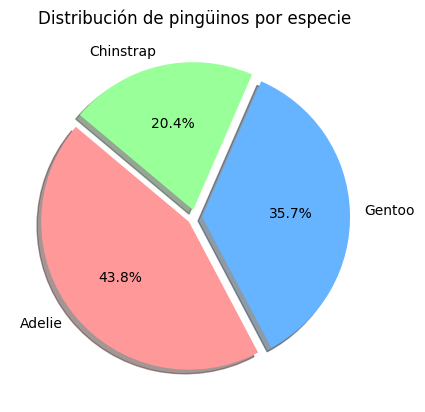

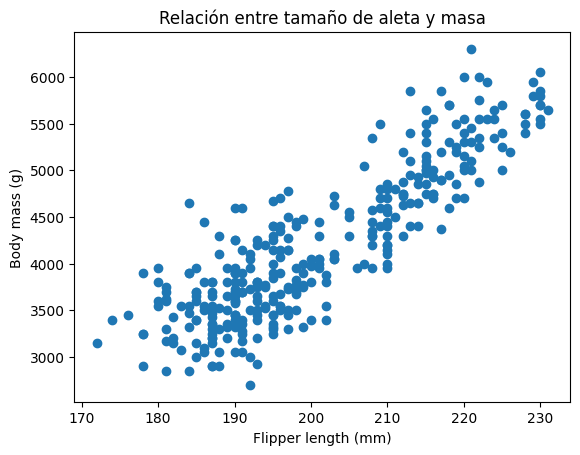

In [36]:
# Estadísticas básicas
print("\nEstadísticas descriptivas:")
print(df.describe())

# Valores faltantes
print("\nValores faltantes:")
print(df.isnull().sum())

# Eliminar filas con NA para trabajar más fácil
df = df.dropna()

# Distribución de especies - CAMBIADO A PASTEL
plt.figure()
df["species"].value_counts().plot(
    kind="pie",
    autopct='%1.1f%%',
    startangle=140,
    shadow=True,
    colors=["#ff9999","#66b3ff","#99ff99"],
    explode=[0.05, 0.05, 0.05]
)
plt.title("Distribución de pingüinos por especie")
plt.ylabel("") # Quitamos el label lateral para que se vea más limpio
plt.show()

# Relación entre longitud de aleta y masa
plt.figure()
plt.scatter(df["flipper_length_mm"], df["body_mass_g"])
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.title("Relación entre tamaño de aleta y masa")
plt.show()

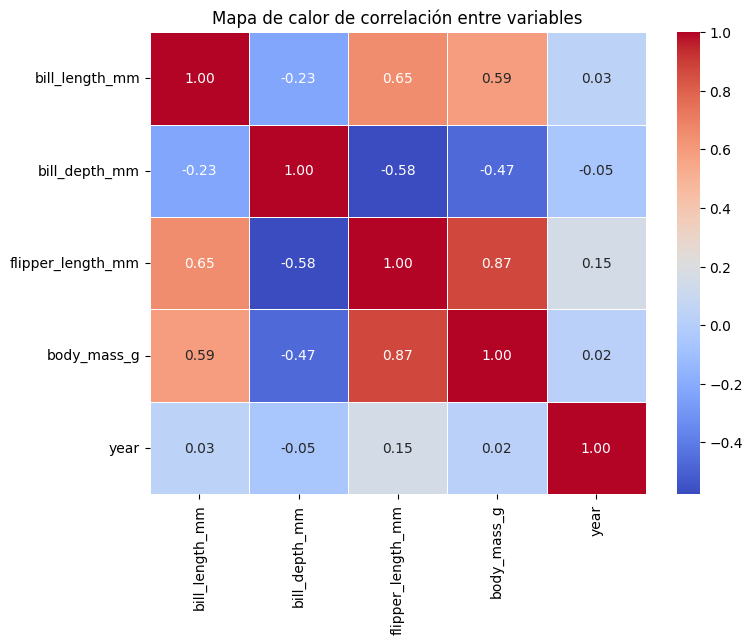

In [26]:
# ==============================
# Mapa de calor de correlación
# ==============================

numeric_df = df[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "year"
]]

# Calcular matriz de correlación
corr_matrix = numeric_df.corr()

# Crear figura
plt.figure(figsize=(8,6))

# Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,        # mostrar números
    cmap="coolwarm",   # colores
    fmt=".2f",         # formato decimal
    linewidths=0.5
)

plt.title("Mapa de calor de correlación entre variables")
plt.show()


w = [50.15326594]
b = -5872.092682842825
R^2 = 0.7620921573403914


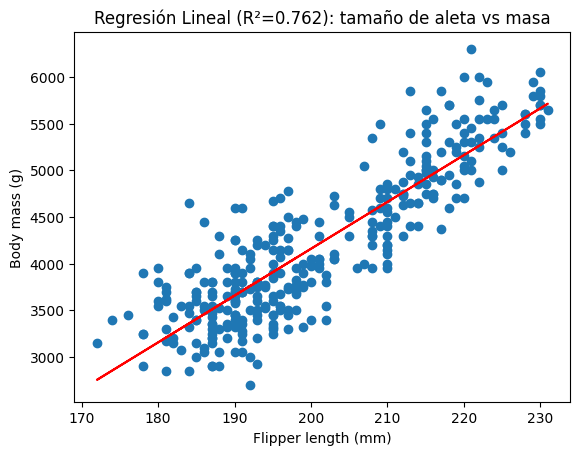

Predicción para flipper_length_mm = 200: [4158.56050561]


In [37]:
# Variable independiente (X)
X = df[["flipper_length_mm"]].values

# Variable dependiente (y)
y = df["body_mass_g"].values

# Crear modelo
linear_regression = LinearRegression()

# Entrenar modelo
linear_regression.fit(X, y)

# Calcular R^2
r2 = linear_regression.score(X, y)

# Mostrar parámetros
print("w =", linear_regression.coef_)
print("b =", linear_regression.intercept_)
print("R^2 =", r2)

# Predicciones
predictions = linear_regression.predict(X)

# Gráfica
plt.figure()
plt.scatter(X, y)
plt.plot(X, predictions, color='red') # Se añade el color rojo aquí
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.title(f"Regresión Lineal (R²={r2:.3f}): tamaño de aleta vs masa")
plt.show()

# Predicción de nueva muestra
new_sample = np.array([[200]])
prediction = linear_regression.predict(new_sample)
print("Predicción para flipper_length_mm = 200:", prediction)

In [25]:
# Variables predictoras
X = df[["bill_length_mm", "bill_depth_mm"]].values

# Convertir especie a números
y = pd.factorize(df["species"])[0]

# Crear modelo
logistic_regression = LogisticRegression()

# Entrenar modelo
logistic_regression.fit(X, y)

print("Modelo entrenado")

# Accuracy del modelo
accuracy = logistic_regression.score(X, y)
print("Accuracy:", accuracy)


Modelo entrenado
Accuracy: 0.963963963963964


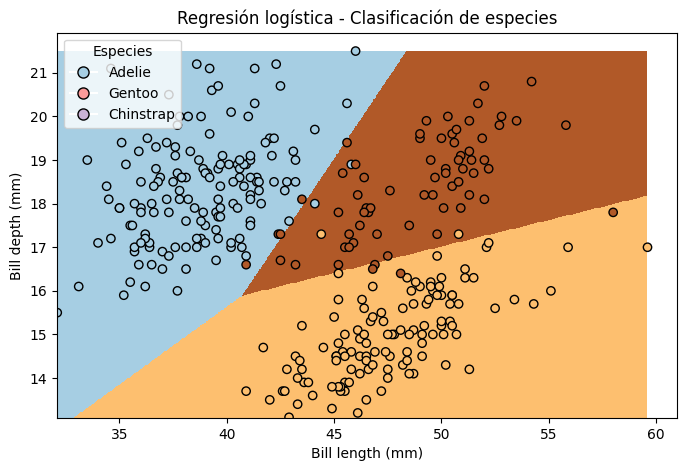

In [17]:
# Límites del gráfico
x_min, x_max = X[:,0].min(), X[:,0].max()
y_min, y_max = X[:,1].min(), X[:,1].max()

# Crear grid
x_grid, y_grid = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predicción del grid
predictions = logistic_regression.predict(
    np.c_[x_grid.ravel(), y_grid.ravel()]
)

predictions = predictions.reshape(x_grid.shape)

# Gráfico
fig, ax = plt.subplots(figsize=(8,5))

# Fondo con regiones de decisión
ax.pcolormesh(x_grid, y_grid, predictions, cmap=plt.cm.Paired, shading='auto')

# Scatter de los datos
scatter = ax.scatter(
    X[:,0], X[:,1],
    c=y,
    edgecolors='k',
    cmap=plt.cm.Paired
)

# Etiquetas
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
ax.set_title("Regresión logística - Clasificación de especies")

# Crear leyenda manual
species_labels = ["Adelie", "Gentoo", "Chinstrap"]
handles = []

for i, label in enumerate(species_labels):
    handles.append(
        plt.Line2D([], [], marker='o', color='w',
                   markerfacecolor=plt.cm.Paired(i/3),
                   markeredgecolor='k',
                   label=label,
                   markersize=8)
    )

ax.legend(handles=handles, title="Especies", loc="upper left")

plt.show()

In [19]:
# ==============================
# REGRESIÓN LOGÍSTICA
# Predecir SEXO
# ==============================

# Variables predictoras
X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].values

# Convertir sexo a números
y = pd.factorize(df["sex"])[0]

# Crear modelo
logistic_regression2 = LogisticRegression(max_iter=200)

# Entrenar modelo
logistic_regression2.fit(X, y)

print("Modelo entrenado para predecir sexo")

# Accuracy del modelo
accuracy = logistic_regression2.score(X, y)
print("Accuracy:", accuracy)


Modelo entrenado para predecir sexo
Accuracy: 0.9099099099099099


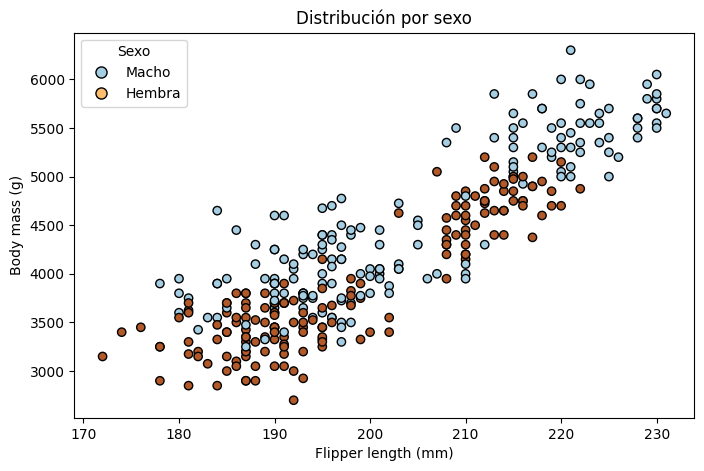

In [30]:
# ==============================
# Visualización del sexo
# ==============================

plt.figure(figsize=(8,5))

scatter = plt.scatter(
    df["flipper_length_mm"],
    df["body_mass_g"],
    c=pd.factorize(df["sex"])[0],
    cmap=plt.cm.Paired,
    edgecolors="k"
)

plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.title("Distribución por sexo")

# Crear leyenda
labels = ["Macho", "Hembra"]
handles = []

for i, label in enumerate(labels):
    handles.append(
        plt.Line2D([], [], marker='o', color='w',
                   markerfacecolor=plt.cm.Paired(i/2),
                   markeredgecolor='k',
                   label=label,
                   markersize=8)
    )

plt.legend(handles=handles, title="Sexo")

plt.show()


In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Variables predictoras
X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]

# Variable objetivo
y = df["species"]

# Crear modelo
tree_model = DecisionTreeClassifier(max_depth=3)

# Entrenar modelo
tree_model.fit(X, y)

print("Árbol de decisión entrenado")

# Accuracy
accuracy = tree_model.score(X, y)
print("Accuracy:", accuracy)


Árbol de decisión entrenado
Accuracy: 0.96996996996997


# **Paradoja de Simpson**

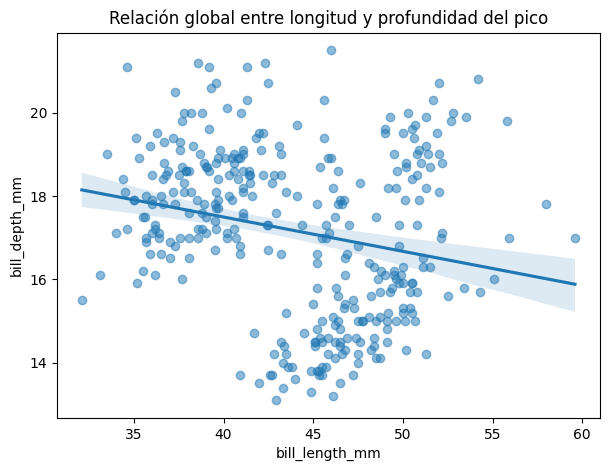

In [33]:
# Scatter de todos los datos juntos
plt.figure(figsize=(7,5))
sns.regplot(
    x="bill_length_mm",
    y="bill_depth_mm",
    data=df,
    scatter_kws={"alpha":0.5}
)

plt.title("Relación global entre longitud y profundidad del pico")
plt.show()


<Figure size 700x500 with 0 Axes>

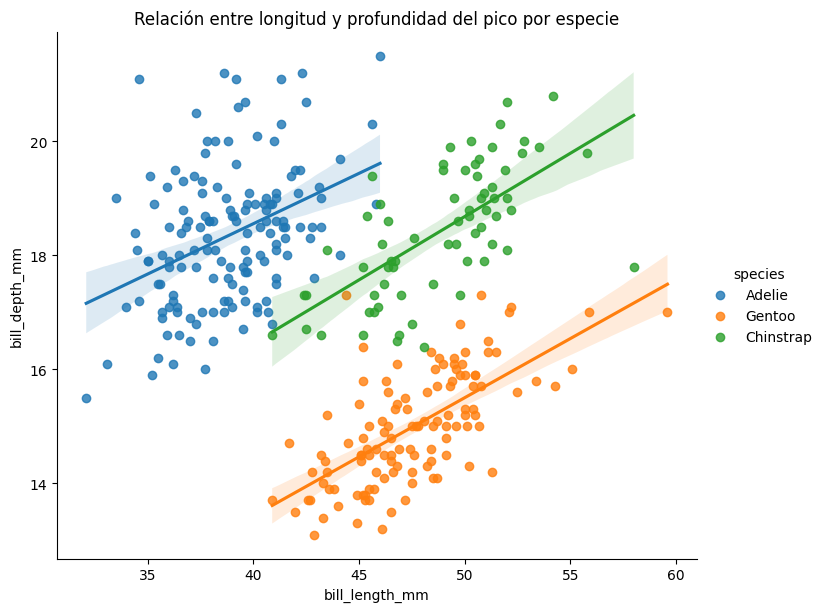

In [34]:
plt.figure(figsize=(7,5))

sns.lmplot(
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    data=df,
    height=6,
    aspect=1.2
)

plt.title("Relación entre longitud y profundidad del pico por especie")

plt.show()
